In [ ]:
import torch
import cv2
import torch.nn.functional as F
import matplotlib.pyplot as plt
plt.style.use('default')
import numpy as np

from dataset.utils.preprocess import preprocess
from core.model import Model
from util.get_default_args import args
from util.warping import warp_backward as warp
from util.utils import fill_depth_map

# %matplotlib tk

In [4]:
model = Model(args)
model_path = 'outputs/20260417_172945/step_000001600/checkpoint.pth'

checkpoint = torch.load(model_path)
model.load_state_dict(checkpoint['model'], strict=True)
model.to('cuda')
model.eval()

Model(
  (encoder): DinoVisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
      (norm): Identity()
    )
    (blocks): ModuleList(
      (0-11): 12 x NestedTensorBlock(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): MemEffAttention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=1536, out_features=384, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
       

In [63]:

folder = 'val'
name = '20260108_151808_754'
left_img_path = rf'F:\dataset\stereo_matching_dataset\{folder}\{name}\color_left_{name}.jpg'
right_img_path = rf'F:\dataset\stereo_matching_dataset\{folder}\{name}\color_right_{name}.jpg'
left_mask_path = rf'F:\dataset\stereo_matching_dataset\{folder}\{name}\target_mask_left_{name}.png'
right_mask_path = rf'F:\dataset\stereo_matching_dataset\{folder}\{name}\target_mask_right_{name}.png'
normal_path = rf'F:\dataset\stereo_matching_dataset\{folder}\{name}\normal_left_{name}.png'
depth_path = rf'F:\dataset\stereo_matching_dataset\{folder}\{name}\depth_{name}.png'\
    if folder == 'val' else None


In [64]:
sample = preprocess(left_img_path, right_img_path, normal_path, left_mask_path, right_mask_path, depth_path)

In [65]:
with torch.no_grad():
    output = model(sample['left_image'], sample['right_image'], sample=sample)
    disp_pred_raw = output[3][-1].unsqueeze(0)
    disp_pred = F.interpolate(disp_pred_raw, size=sample['size'], mode='bilinear', align_corners=False).squeeze().cpu().numpy()

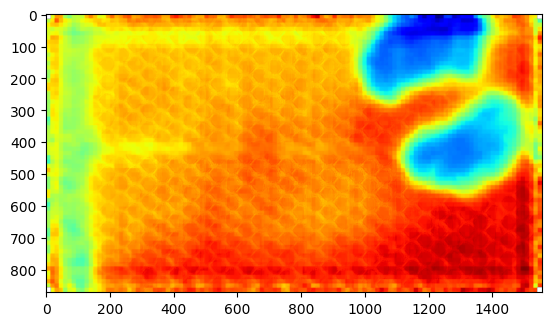

In [66]:
disp_pred[:15, :15] = np.nan
disp_pred[:15, -15:] = np.nan
disp_pred[-15:, :15] = np.nan
disp_pred[-15:, -15:] = np.nan
plt.imshow(disp_pred, cmap='jet_r')


In [67]:
depth_gt = cv2.imread(depth_path, cv2.IMREAD_ANYDEPTH|cv2.IMREAD_ANYCOLOR)*0.1
depth_gt[depth_gt == 0] = np.nan
disp_gt = 1380*119 / depth_gt
disp_gt = fill_depth_map(disp_gt)

plt.imsave(f'demo/{name}.jpg', np.ma.masked_invalid(disp_pred), cmap='jet_r')
plt.imsave(f'demo/{name}_gt.jpg', np.ma.masked_invalid(disp_gt), cmap='jet_r')

In [68]:
np.nanmean(disp_pred)

196.5406

In [69]:
# left_image = sample['left_image_raw']
# right_img = sample['right_image_raw']
# left_image_sys, warp_mask = warp(right_img.permute(2, 0, 1).unsqueeze(0).float(), disp_pred_raw[0].cpu())

# plt.figure()
# plt.subplot(2, 1, 1)
# plt.imshow(left_image.numpy())
# plt.subplot(2, 1, 2)
# plt.imshow(left_image_sys.squeeze().permute(1, 2, 0).cpu().numpy().astype(np.uint8))

# plt.figure()
# plt.imshow(disp_pred, cmap='jet_r')

# plt.show()

In [70]:
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt

# depth_map_vis_path = 'outputs/20260417_172945/step_000001600/predictions/val_015_disp_pred.jpg'
# depth_map_vis = cv2.cvtColor(cv2.imread(depth_map_vis_path), cv2.COLOR_BGR2RGB)

# # 将白色像素点替换为灰色
# depth_map_vis[np.all(depth_map_vis == [255, 255, 255], axis=-1)] = [128, 128, 128]
# plt.imsave('outputs/20260417_172945/step_000001600/predictions/val_015_disp_pred_processed.jpg', depth_map_vis)

In [1]:
import os
l = os.listdir(r'F:\dataset\stereo_matching_dataset\val')
l.sort()
[l.index(i) for i in [
    '20260108_115044_769',
    '20260108_140106_745',
    '20260108_140459_325',
    '20260108_144900_206',
    '20260108_151808_754'
]]

[6, 10, 11, 21, 27]